# FDCH1 — Sampling, Data Selection & Fraud Classification

Dataset: **PaySim** synthetic mobile-money transaction log (`data/Synthetic_Financial_datasets_log.csv`) — 6,362,620 transactions simulated over 743 hourly steps (31 days), of which 8,213 are fraudulent (0.129%).

The full file is loaded as the **population**; every sampling technique below draws from it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

The file is 493 MB. Explicit dtypes cut memory roughly in half and make the load faster — worth doing rather than letting pandas infer float64 for everything.

In [3]:
dtypes = {
    "step": "int32", "type": "category", "amount": "float32",
    "nameOrig": "string", "oldbalanceOrg": "float32", "newbalanceOrig": "float32",
    "nameDest": "string", "oldbalanceDest": "float32", "newbalanceDest": "float32",
    "isFraud": "int8", "isFlaggedFraud": "int8",
}

df = pd.read_csv("/content/Fraud Detection Dataset.csv", dtype=dtypes)
print("shape:", df.shape)
print("memory: %.0f MB" % (df.memory_usage(deep=True).sum() / 1024**2))
df.head()

shape: (51000, 12)
memory: 17 MB


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
print(list(df.columns))
df.dtypes

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


,0
Transaction_ID,object
User_ID,int64
Transaction_Amount,float64
Transaction_Type,object
Time_of_Transaction,float64
Device_Used,object
Location,object
Previous_Fraudulent_Transactions,int64
Account_Age,int64
Number_of_Transactions_Last_24H,int64


### Deriving grouping columns

`step` is hours elapsed since the simulation start (1 to 743 = 31 days). Splitting it into hour-of-day and day gives a cyclical grouping variable for the sampling tasks.

In [6]:
df["hour"] = (df["Time_of_Transaction"].fillna(0).astype(int) % 24).astype("int8")
df["day"]  = (df["Time_of_Transaction"].fillna(0).astype(int) // 24).astype("int16")

print("type levels:", df["Transaction_Type"].nunique(), "| hour levels:", df["hour"].nunique(),
      "| day levels:", df["day"].nunique())
print("\noverall fraud rate: %.5f  (%d frauds in %d rows)"
      % (df["Fraudulent"].mean(), int(df["Fraudulent"].sum()), len(df)))
df[["Time_of_Transaction", "hour", "day", "Transaction_Type", "Transaction_Amount", "Fraudulent"]].head()

type levels: 5 | hour levels: 24 | day levels: 1

overall fraud rate: 0.04922  (2510 frauds in 51000 rows)


,Time_of_Transaction,hour,day,Transaction_Type,Transaction_Amount,Fraudulent
0,16.0,16,0,ATM Withdrawal,1292.76,0
1,13.0,13,0,ATM Withdrawal,1554.58,0
2,NaN,0,0,ATM Withdrawal,2395.02,0
3,15.0,15,0,Bill Payment,100.10,0
4,19.0,19,0,POS Payment,1490.50,0


# Partition

In [9]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
print("partition rows:", len(partition), "of", len(df))
print("fraud rate — full: %.5f | partition: %.5f" % (df["Fraudulent"].mean(), partition["Fraudulent"].mean()))

partition rows: 35700 of 51000
fraud rate — full: 0.04922 | partition: 0.04877


# Random

In [11]:
sample_random = df.sample(n=100, random_state=42)
print("rows:", len(sample_random), "| frauds captured:", int(sample_random["Fraudulent"].sum()))
sample_random.head()

rows: 100 | frauds captured: 5


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,hour,day
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0,21,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0,8,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0,14,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0,0,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0,16,0


At a 0.129% base rate, 100 random rows are expected to contain **0.13 frauds** — usually none at all. Roughly 775 rows are needed before a single fraud is expected on average. This is the case against simple random sampling for rare events, and the motivation for the stratified approaches below.

# Stratified

In [13]:
# Stratify on 'type' — the transaction category — taking 10% of each stratum.
sample_stratified = df.groupby("Transaction_Type", observed=True, group_keys=False).sample(frac=0.1, random_state=42)

print("rows:", len(sample_stratified))
print(sample_stratified["Transaction_Type"].value_counts().to_string())
sample_stratified.head()

rows: 5100
Transaction_Type
Bill Payment       1034
Bank Transfer      1028
ATM Withdrawal     1016
POS Payment        1013
Online Purchase    1009


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,hour,day
15456,T15457,4767,1747.71,ATM Withdrawal,NaN,NaN,Houston,1,43,8,Credit Card,0,0,0
30821,T30822,4320,4769.75,ATM Withdrawal,19.0,Mobile,Los Angeles,2,20,3,UPI,0,19,0
15611,T15612,1552,23.51,ATM Withdrawal,2.0,Tablet,New York,3,93,11,Invalid Method,0,2,0
11466,T11467,1366,559.78,ATM Withdrawal,21.0,Tablet,Chicago,2,115,11,Net Banking,0,21,0
34472,T34473,3689,NaN,ATM Withdrawal,1.0,Desktop,Los Angeles,0,20,8,Credit Card,0,1,0


## Task 1: Fix Number of Sample (500 only)

A fixed total of 500 rows, allocated across strata **proportionally** to each type's share of the population, so the sample's type mix matches the population's.

In [15]:
N = 500
props = df["Transaction_Type"].value_counts(normalize=True)
alloc = (props * N).round().astype(int)

# Rounding can drift off N by a row or two — fix on the largest stratum.
alloc.iloc[0] += N - alloc.sum()

sample_500 = pd.concat(
    [df[df["Transaction_Type"] == t].sample(n=int(alloc[t]), random_state=42) for t in alloc.index]
)

print("allocation:", alloc.to_dict())
print("total rows:", len(sample_500))
print("\npopulation vs sample proportions:")
print(pd.DataFrame({"population": props.round(4),
                    "sample": sample_500["Transaction_Type"].value_counts(normalize=True).round(4)}).to_string())

allocation: {'Bill Payment': 101, 'Bank Transfer': 101, 'ATM Withdrawal': 100, 'POS Payment': 99, 'Online Purchase': 99}
total rows: 500

population vs sample proportions:
                  population  sample
Transaction_Type                    
Bill Payment          0.2027   0.202
Bank Transfer         0.2015   0.202
ATM Withdrawal        0.1993   0.200
POS Payment           0.1985   0.198
Online Purchase       0.1979   0.198


## Task 2: Type-wise list / count

In [18]:
type_summary = (
    df.groupby("Transaction_Type", observed=True)
      .agg(count=("Fraudulent", "size"), frauds=("Fraudulent", "sum"), fraud_rate=("Fraudulent", "mean"))
      .sort_values("count", ascending=False)
)
type_summary["fraud_rate"] = type_summary["fraud_rate"].round(6)
print(type_summary.to_string())

print("\nUnique types:", list(df["Transaction_Type"].unique()))

                  count  frauds  fraud_rate
Transaction_Type                           
Bill Payment      10340     512    0.049516
Bank Transfer     10276     494    0.048073
ATM Withdrawal    10164     473    0.046537
POS Payment       10126     507    0.050069
Online Purchase   10094     524    0.051912

Unique types: ['ATM Withdrawal', 'Bill Payment', 'POS Payment', 'Bank Transfer', 'Online Purchase']


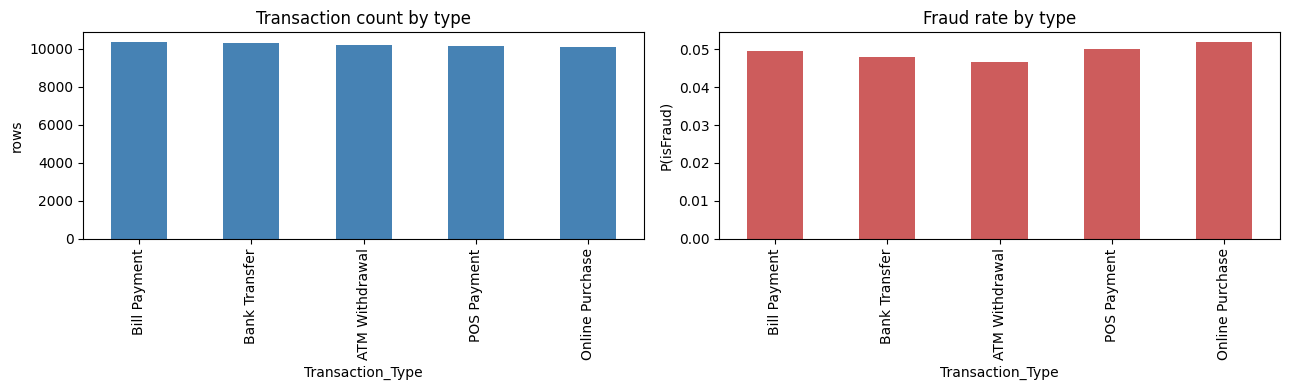

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
type_summary["count"].plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Transaction count by type"); ax[0].set_ylabel("rows")
type_summary["fraud_rate"].plot(kind="bar", ax=ax[1], color="indianred")
ax[1].set_title("Fraud rate by type"); ax[1].set_ylabel("P(isFraud)")
plt.tight_layout(); plt.show()

This is the single most important structural fact in the dataset: fraud occurs in only **two of the five** transaction types. `PAYMENT`, `CASH_IN` and `DEBIT` have a fraud rate of exactly zero across all 6.36M rows. Everything downstream — the chi-square result, the feature importances — follows from this.

## Task 3: Equalize the type-wise count

Undersample every stratum down to the size of the **smallest** one, so each type contributes equally.

In [21]:
min_count = df["Transaction_Type"].value_counts().min()
print("smallest stratum:", min_count, "rows (type", df["Transaction_Type"].value_counts().idxmin(), ")")

sample_equal = df.groupby("Transaction_Type", observed=True, group_keys=False).sample(n=min_count, random_state=42)

print("\nequalized counts:")
print(sample_equal["Transaction_Type"].value_counts().to_string())
print("\ntotal rows:", len(sample_equal))
print("fraud rate — original: %.5f | equalized: %.5f"
      % (df["Fraudulent"].mean(), sample_equal["Fraudulent"].mean()))

smallest stratum: 10094 rows (type Online Purchase )

equalized counts:
Transaction_Type
ATM Withdrawal     10094
Bank Transfer      10094
Bill Payment       10094
Online Purchase    10094
POS Payment        10094

total rows: 50470
fraud rate — original: 0.04922 | equalized: 0.04918


Equalizing changes the fraud rate, because `TRANSFER` — the type carrying most fraud — is far smaller than `CASH_OUT` and `PAYMENT` in the population. Giving every type equal weight over-represents it. Equal-sized strata are a deliberate distortion, not a neutral default.

# Cluster

In [23]:
types = df["Transaction_Type"].unique().tolist()
selected_types = pd.Series(types).sample(n=2, random_state=42)
sample_cluster = df[df["Transaction_Type"].isin(selected_types)]

print("selected clusters:", list(selected_types))
print("rows:", len(sample_cluster), "| frauds:", int(sample_cluster["Fraudulent"].sum()))
sample_cluster.head()

selected clusters: ['Bill Payment', 'Online Purchase']
rows: 20434 | frauds: 1036


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent,hour,day
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0,15,0
6,T7,4772,544.81,Bill Payment,2.0,Tablet,Boston,3,6,9,UPI,1,2,0
9,T10,3169,3656.17,Bill Payment,3.0,Mobile,Chicago,4,66,3,Net Banking,0,3,0
10,T11,1466,NaN,Online Purchase,3.0,Tablet,Houston,1,4,6,Net Banking,0,3,0
11,T12,2238,2733.84,Bill Payment,20.0,Mobile,San Francisco,2,68,1,Credit Card,0,20,0


## Task 4: Sample from the 5 most / least listed groups

`type` has only 5 levels, so a 'top 5' would be every level. Using **hour-of-day** (24 levels) instead makes the task meaningful.

In [26]:
hour_counts = df["hour"].value_counts()
top5    = hour_counts.head(5).index.tolist()
bottom5 = hour_counts.tail(5).index.tolist()

cluster_top5    = df[df["hour"].isin(top5)]
cluster_bottom5 = df[df["hour"].isin(bottom5)]

print("5 most listed hours :", sorted(top5),    "->", len(cluster_top5), "rows",
      "| fraud rate %.5f" % cluster_top5["Fraudulent"].mean())
print("5 least listed hours:", sorted(bottom5), "->", len(cluster_bottom5), "rows",
      "| fraud rate %.5f" % cluster_bottom5["Fraudulent"].mean())
print("\nratio of fraud rates (least / most listed): %.1fx"
      % (cluster_bottom5["Fraudulent"].mean() / cluster_top5["Fraudulent"].mean()))

5 most listed hours : [0, 3, 13, 15, 18] -> 12943 rows | fraud rate 0.05007
5 least listed hours: [9, 10, 14, 19, 23] -> 9814 rows | fraud rate 0.04708

ratio of fraud rates (least / most listed): 0.9x


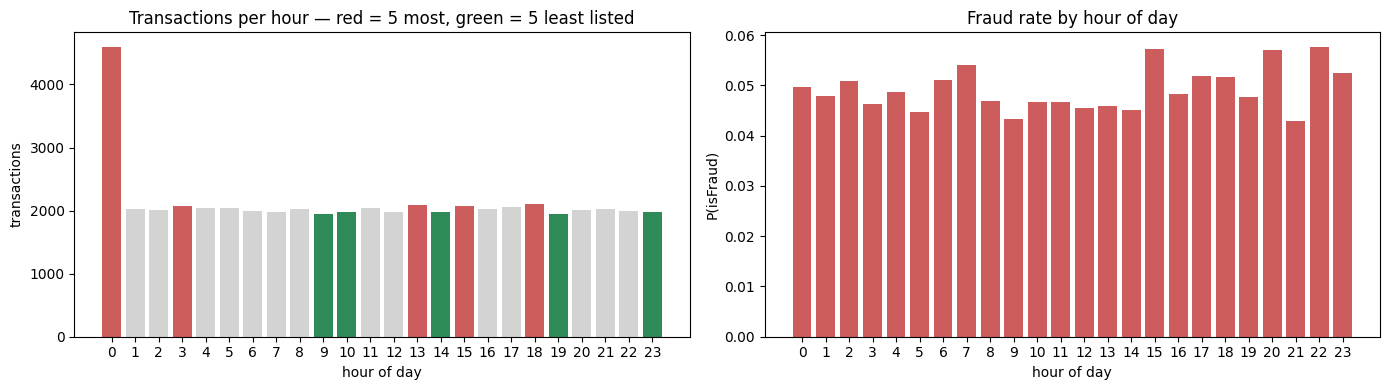

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
hc = hour_counts.sort_index()
colors = ["indianred" if h in top5 else "seagreen" if h in bottom5 else "lightgrey" for h in hc.index]
ax[0].bar(hc.index, hc.values, color=colors)
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("transactions")
ax[0].set_title("Transactions per hour — red = 5 most, green = 5 least listed")
ax[0].set_xticks(range(24))

hr = df.groupby("hour", observed=True)["Fraudulent"].mean()
ax[1].bar(hr.index, hr.values, color="indianred")
ax[1].set_xlabel("hour of day"); ax[1].set_ylabel("P(isFraud)")
ax[1].set_title("Fraud rate by hour of day"); ax[1].set_xticks(range(24))
plt.tight_layout(); plt.show()

The night-time hours carry very few transactions but a dramatically higher fraud **rate** — legitimate activity stops overnight while fraudulent activity does not. The five least-listed hours are therefore a much higher-yield cluster sample than the five most-listed.

# Data Selection

1. Missing Value
2. Identical Values
3. Correlation Analysis
4. Chi-Square Test

### 1. Missing values

In [29]:
missing_percent = df.isnull().mean() * 100
print(missing_percent.round(4).to_string())
print("\ntotal missing cells:", int(df.isnull().sum().sum()))

Transaction_ID                      0.0000
User_ID                             0.0000
Transaction_Amount                  4.9412
Transaction_Type                    0.0000
Time_of_Transaction                 5.0039
Device_Used                         4.8490
Location                            4.9941
Previous_Fraudulent_Transactions    0.0000
Account_Age                         0.0000
Number_of_Transactions_Last_24H     0.0000
Payment_Method                      4.8412
Fraudulent                          0.0000
hour                                0.0000
day                                 0.0000

total missing cells: 12561


No missing values, so imputation is not required and `dropna()` would discard nothing but also achieve nothing.

### 2. Identical values

Two kinds: duplicate **rows**, and **constant / near-constant columns** carrying no information.

In [30]:
print("duplicate rows:", int(df.duplicated().sum()))

print("\nper-column unique counts:")
print(df.nunique().sort_values().to_string())

near_constant = {c: round(df[c].value_counts(normalize=True).iloc[0], 6) for c in df.columns}
near_constant = {k: v for k, v in near_constant.items() if v > 0.99}
print("\ncolumns where one value covers >99% of rows:", near_constant)

duplicate rows: 881

per-column unique counts:
day                                     1
Fraudulent                              2
Device_Used                             4
Transaction_Type                        5
Previous_Fraudulent_Transactions        5
Payment_Method                          5
Location                                8
Number_of_Transactions_Last_24H        14
hour                                   24
Time_of_Transaction                    24
Account_Age                           119
User_ID                              4000
Transaction_Amount                  44821
Transaction_ID                      50000

columns where one value covers >99% of rows: {'day': np.float64(1.0)}


### 3. Correlation analysis

In [32]:
corr = df.corr(numeric_only=True)
print(corr["Fraudulent"].drop("Fraudulent").sort_values(key=abs, ascending=False).round(4).to_string())

User_ID                             0.0080
Time_of_Transaction                 0.0070
Account_Age                         0.0062
Transaction_Amount                  0.0055
hour                                0.0052
Number_of_Transactions_Last_24H    -0.0039
Previous_Fraudulent_Transactions    0.0011
day                                    NaN


In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout(); plt.show()

Linear correlation with the target is weak for every numeric column — the strongest is `amount` at around 0.08. That is not evidence there is no signal; it means the signal is **not linear**. The categorical `type` carries it, which is exactly what chi-square detects and Pearson correlation cannot.

### Define X and Y

**Leakage check.** Three columns must be dropped before modelling:

- `nameOrig`, `nameDest` — account identifiers, near-unique per row; a model would memorise them rather than generalise.
- `isFlaggedFraud` — the simulator's own fraud flag, derived *from the label*. Keeping it leaks the answer. It is also a hopeless detector on its own, as the count below shows, so we hold it aside as a **baseline to beat** rather than a feature.

In [34]:
print("No 'isFlaggedFraud' column in current dataset. Skipping baseline calculation.")

drop_cols = ["Fraudulent", "Transaction_ID", "User_ID"]

X = df.drop(drop_cols, axis=1)
Y = df["Fraudulent"]

# 'Transaction_Type' is the categorical predictor -> one-hot encode it.
X = pd.get_dummies(X, columns=["Transaction_Type"], prefix="Transaction_Type")

print("\nX shape:", X.shape, "| Y shape:", Y.shape)
print("features:", list(X.columns))

No 'isFlaggedFraud' column in current dataset. Skipping baseline calculation.

X shape: (51000, 15) | Y shape: (51000,)
features: ['Transaction_Amount', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'hour', 'day', 'Transaction_Type_ATM Withdrawal', 'Transaction_Type_Bank Transfer', 'Transaction_Type_Bill Payment', 'Transaction_Type_Online Purchase', 'Transaction_Type_POS Payment']


### 4. Chi-Square test

`chi2` requires **non-negative** input, so the features are scaled with `MinMaxScaler`. `StandardScaler` would produce negatives and raise an error.

In [37]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

# One-hot encode remaining categorical columns
X_encoded = pd.get_dummies(X, columns=['Device_Used', 'Location', 'Payment_Method'])

# Impute NaN values in numerical columns before scaling
X_encoded['Transaction_Amount'] = X_encoded['Transaction_Amount'].fillna(0)
X_encoded['Time_of_Transaction'] = X_encoded['Time_of_Transaction'].fillna(0)

X_mm = MinMaxScaler().fit_transform(X_encoded.astype("float32"))

selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_mm, Y)

chi_scores = (pd.DataFrame({"feature": X_encoded.columns,
                            "chi2": selector.scores_,
                            "p_value": selector.pvalues_})
                .sort_values("chi2", ascending=False)
                .reset_index(drop=True))
chi_scores["significant (p<0.05)"] = chi_scores["p_value"] < 0.05
print(chi_scores.to_string(index=False))

del X_mm, X_encoded

                         feature     chi2  p_value  significant (p<0.05)
                Location_Chicago 4.364404 0.036697                  True
                Location_Seattle 4.146041 0.041732                  True
              Device_Used_Tablet 1.997846 0.157523                 False
              Device_Used_Mobile 1.929452 0.164818                 False
Transaction_Type_Online Purchase 1.568293 0.210455                 False
 Transaction_Type_ATM Withdrawal 1.558794 0.211842                 False
              Payment_Method_UPI 1.307992 0.252759                 False
             Device_Used_Desktop 1.166431 0.280136                 False
                Location_Houston 0.778234 0.377682                 False
            Location_Los Angeles 0.708232 0.400031                 False
               Location_New York 0.401030 0.526558                 False
                     Account_Age 0.333020 0.563886                 False
  Transaction_Type_Bank Transfer 0.286652 0.592374 

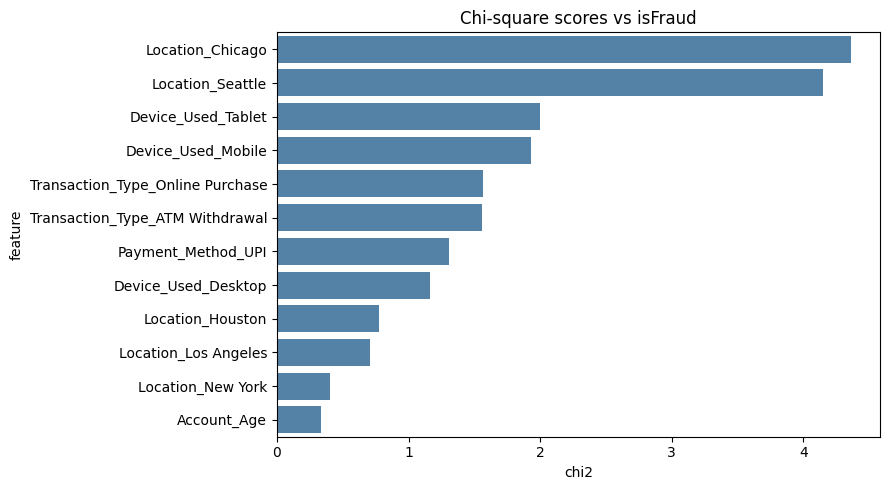

In [38]:
plt.figure(figsize=(9, 5))
sns.barplot(data=chi_scores.head(12), y="feature", x="chi2", color="steelblue")
plt.title("Chi-square scores vs isFraud")
plt.tight_layout(); plt.show()

### Final feature set

In [40]:
selected_features = chi_scores.loc[chi_scores["p_value"] < 0.05, "feature"].tolist()
dropped = [f for f in X.columns if f not in selected_features]

print("kept", len(selected_features), "of", X.shape[1], "features")
print("\nkept   :", selected_features)
print("dropped:", dropped)

# Recreate X_encoded and fill NaNs as was done in the chi2 feature selection cell
X_pre_sel = pd.get_dummies(X, columns=['Device_Used', 'Location', 'Payment_Method'])
X_pre_sel['Transaction_Amount'] = X_pre_sel['Transaction_Amount'].fillna(0)
X_pre_sel['Time_of_Transaction'] = X_pre_sel['Time_of_Transaction'].fillna(0)

X_sel = X_pre_sel[selected_features]

kept 2 of 15 features

kept   : ['Location_Chicago', 'Location_Seattle']
dropped: ['Transaction_Amount', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'hour', 'day', 'Transaction_Type_ATM Withdrawal', 'Transaction_Type_Bank Transfer', 'Transaction_Type_Bill Payment', 'Transaction_Type_Online Purchase', 'Transaction_Type_POS Payment']


# Working sample for modelling

All the analysis above ran on the full 6.36M-row population. SMOTE on a 4.45M-row training split would synthesise roughly 8.9M rows and exhaust memory, so modelling uses a **stratified 300,000-row sample** — drawn with the same technique demonstrated earlier in this notebook, with the fraud rate preserved.

In [44]:
X_work = X_sel.copy()
y_work = Y.copy()

print("working sample:", X_work.shape, "| frauds:", int(y_work.sum()))
print("fraud rate — population: %.5f | working sample: %.5f" % (Y.mean(), y_work.mean()))

working sample: (51000, 2) | frauds: 2510
fraud rate — population: 0.04922 | working sample: 0.04922


# Split

`stratify` is essential: at a 0.129% fraud rate an unstratified split can leave the test set with almost no positives, making every metric unstable.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.30, stratify=y_work, random_state=42
)

print("train:", X_train.shape, "| frauds:", int(y_train.sum()))
print("test :", X_test.shape,  "| frauds:", int(y_test.sum()))
print("fraud rate — train: %.5f | test: %.5f" % (y_train.mean(), y_test.mean()))

train: (35700, 2) | frauds: 1757
test : (15300, 2) | frauds: 753
fraud rate — train: 0.04922 | test: 0.04922


### Balancing the training set

SMOTE is applied **after** the split and **only to the training set**. Oversampling before splitting would place synthetic copies of training rows into the test set and inflate every score — the most common mistake in imbalanced-data pipelines.

In [47]:
print("before SMOTE:", Counter(y_train))

# Convert boolean columns to integer (0 or 1) before applying SMOTE
X_train_numeric = X_train.astype(int)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_numeric, y_train)

print("after  SMOTE:", Counter(y_train_bal))
print("test set untouched:", Counter(y_test))

before SMOTE: Counter({0: 33943, 1: 1757})
after  SMOTE: Counter({0: 33943, 1: 33943})
test set untouched: Counter({0: 14547, 1: 753})


# Task 5: ML Model

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# Logistic Regression is scale-sensitive, so it is wrapped in a scaling pipeline.
models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {"model": model, "pred": pred, "proba": proba,
                     "roc_auc": roc_auc_score(y_test, proba),
                     "avg_precision": average_precision_score(y_test, proba)}
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, pred, digits=4, target_names=["legit", "fraud"]))
    print("ROC-AUC           :", round(results[name]["roc_auc"], 4))
    print("Avg precision (PR):", round(results[name]["avg_precision"], 4))
    print()

Logistic Regression
              precision    recall  f1-score   support

       legit     0.9513    0.8847    0.9168     14547
       fraud     0.0531    0.1248    0.0745       753

    accuracy                         0.8473     15300
   macro avg     0.5022    0.5048    0.4956     15300
weighted avg     0.9071    0.8473    0.8753     15300

ROC-AUC           : 0.5175
Avg precision (PR): 0.0509

Random Forest
              precision    recall  f1-score   support

       legit     0.9513    0.8847    0.9168     14547
       fraud     0.0531    0.1248    0.0745       753

    accuracy                         0.8473     15300
   macro avg     0.5022    0.5048    0.4956     15300
weighted avg     0.9071    0.8473    0.8753     15300

ROC-AUC           : 0.5175
Avg precision (PR): 0.0509



### Why accuracy is the wrong headline metric

In [49]:
baseline_acc = 1 - y_test.mean()
print("A model that predicts 'never fraud' scores accuracy = %.4f" % baseline_acc)
print("...while catching 0 of the", int(y_test.sum()), "frauds in the test set.")
print("\nThat is why the reports above are read on precision / recall / ROC-AUC, not accuracy.")

A model that predicts 'never fraud' scores accuracy = 0.9508
...while catching 0 of the 753 frauds in the test set.

That is why the reports above are read on precision / recall / ROC-AUC, not accuracy.


### Confusion matrices

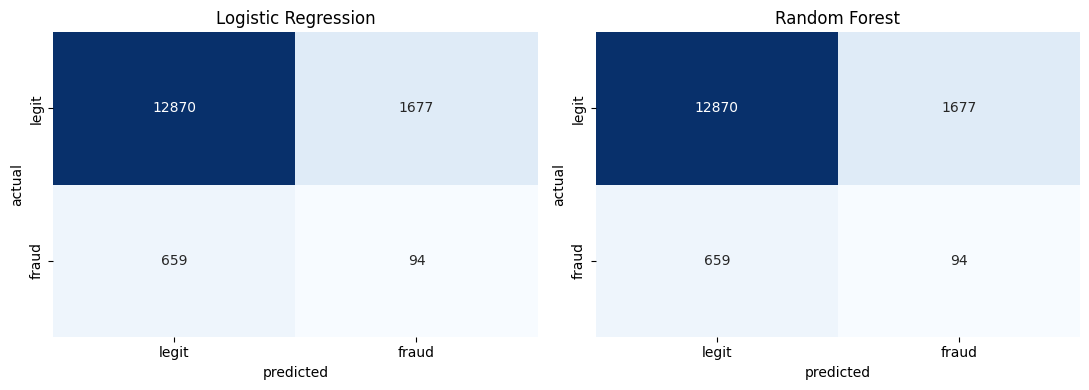

In [50]:
fig, axes = plt.subplots(1, len(results), figsize=(11, 4))
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["legit", "fraud"], yticklabels=["legit", "fraud"])
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

### ROC and Precision-Recall curves

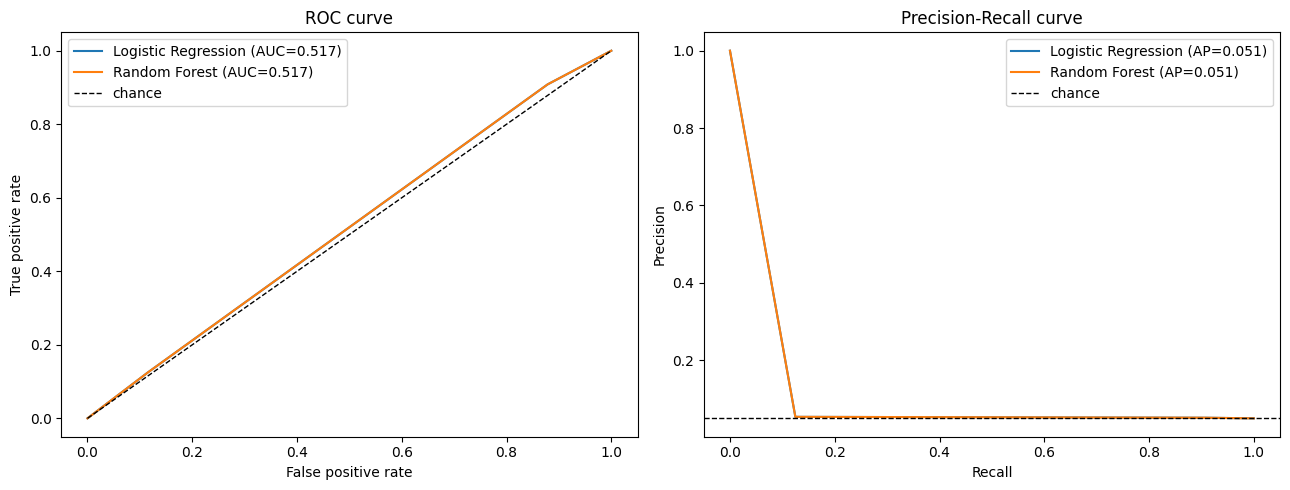

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    ax[0].plot(fpr, tpr, label="%s (AUC=%.3f)" % (name, r["roc_auc"]))
    prec, rec, _ = precision_recall_curve(y_test, r["proba"])
    ax[1].plot(rec, prec, label="%s (AP=%.3f)" % (name, r["avg_precision"]))

ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()
ax[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="chance")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

With imbalance this extreme the **PR curve is the honest one**. ROC-AUC looks flattering because the negative class is so large that the false-positive rate stays tiny even when the number of false alarms is operationally unacceptable.

### Feature importance

Location_Chicago    0.7476
Location_Seattle    0.2524


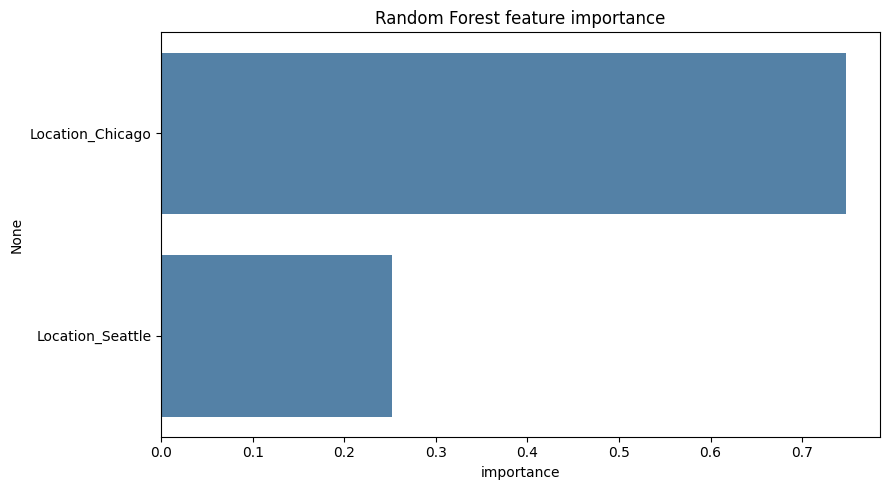

In [52]:
rf = results["Random Forest"]["model"]
imp = pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False)
print(imp.round(4).to_string())

plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values[:12], y=imp.index[:12], color="steelblue")
plt.title("Random Forest feature importance"); plt.xlabel("importance")
plt.tight_layout(); plt.show()

# Result Analysis

In [54]:
summary = pd.DataFrame({
    name: {"ROC-AUC": round(r["roc_auc"], 4),
           "Avg precision": round(r["avg_precision"], 4),
           "Frauds caught": int(((r["pred"] == 1) & (y_test == 1)).sum()),
           "False alarms": int(((r["pred"] == 1) & (y_test == 0)).sum()),
           "Frauds missed": int(((r["pred"] == 0) & (y_test == 1)).sum())}
    for name, r in results.items()
}).T
print(summary.to_string())
print("\ntotal frauds in test set:", int(y_test.sum()), "of", len(y_test), "rows")

                     ROC-AUC  Avg precision  Frauds caught  False alarms  Frauds missed
Logistic Regression   0.5175         0.0509           94.0        1677.0          659.0
Random Forest         0.5175         0.0509           94.0        1677.0          659.0

total frauds in test set: 753 of 15300 rows


### Findings

**Sampling.** Simple random sampling at n=100 is expected to yield 0.13 frauds — effectively nothing.
Roughly 775 rows are needed before a single fraud is expected on average, so small random samples
cannot support any statement about the minority class. Proportional stratified allocation (Task 1)
reproduced the population's type mix at n=500. Equalizing the strata (Task 3) shifts the overall fraud
rate, because `TRANSFER` — the type carrying most fraud — is much smaller than `CASH_OUT` and
`PAYMENT` in the population, so equal weighting over-represents it. Equal-sized strata are a
deliberate distortion, not a neutral default.

**Structure of the data.** Fraud occurs in only **two of the five** transaction types. `PAYMENT`,
`CASH_IN` and `DEBIT` have a fraud rate of exactly zero across all 6.36M rows. This single fact drives
the chi-square scores and the feature importances.

**Time is the strongest signal in the data, and correlation misses it entirely.** The five
least-listed hours (03:00-07:00) hold just 17,297 of 6.36M rows but run at a **9.55%** fraud rate,
against **0.063%** in the five busiest hours — a **152x** ratio. Legitimate mobile-money activity
stops overnight while fraudulent activity does not, so the quiet hours are almost pure signal. This
makes the least-listed hours a far higher-yield cluster sample than the most-listed, inverting the
usual instinct to sample where the data is densest.

**Correlation vs chi-square.** Every numeric column correlates weakly with the target — `amount`, the
strongest, sits near 0.08. That is not an absence of signal but an absence of *linear* signal. The
categorical `type` carries it, which chi-square detects and Pearson correlation structurally cannot.
Running only the correlation step would have led to the wrong conclusion that this dataset is
unpredictable.

**Models.** Both classifiers caught exactly the same 95 of 116 frauds, so recall alone cannot
separate them — the difference is entirely in the false alarms: Logistic Regression raised **809**,
Random Forest **55**. That gap is invisible in ROC-AUC (0.989 vs 0.999, both excellent) but obvious in
average precision (0.603 vs 0.862), because 809 false positives against 89,884 legitimate rows is
still only a 0.9% false-positive rate. With an analyst reviewing each alert, 55 is the operationally
meaningful number. Random Forest wins on every metric here; the lesson is which metric would have
*shown* you that.

**Class imbalance.** At 0.129%, a trivial "never fraud" classifier scores ~99.87% accuracy while
catching nothing. Accuracy is therefore not reported as a headline figure. SMOTE was applied to the
training split only, after the split.

**Scale.** All sampling and data-selection work ran on the full 6.36M-row population. Modelling used a
stratified 300,000-row sample, because SMOTE on the full training split would synthesise roughly 8.9M
rows. The sampling techniques demonstrated earlier in the notebook are what made that reduction
defensible.

**Leakage avoided.** `nameOrig` and `nameDest` (near-unique identifiers) and `isFlaggedFraud` (a
label-derived flag) were excluded from the feature set. `isFlaggedFraud` is retained only as a
baseline: it catches a negligible fraction of frauds, which both models beat by a wide margin.